# Assignment 1 — Reinforcement Learning


Team:
1. Mohamed Hesham 20220310
2. Mohamed Islam 20220282
3. Ali Mohamed 20220211
4. Amr Mustafa 20220238
5. Ziad Hosny 20220145

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import gymnasium as gym
import warnings
warnings.filterwarnings('ignore')

---
## Section 1 — OOP Implementation

### 1.1 TaxiEnvironment

In [2]:
class TaxiEnvironment:

    def __init__(self):
        self.env = gym.make('Taxi-v3')
        self.n_states  = self.env.observation_space.n  # 500
        self.n_actions = self.env.action_space.n        # 6
        self.P         = self.env.unwrapped.P           # transition model

    def reset(self):
        state, _ = self.env.reset()
        return state

    def step(self, action):
        return self.env.step(action)

    def render(self):
        env = gym.make('Taxi-v3', render_mode='ansi')
        env.reset()
        print(env.render())
        env.close()

### 1.2 ValueIterationAgent

In [3]:
class ValueIterationAgent:

    def __init__(self, env, gamma=0.99, theta=1e-8):
        self.env    = env
        self.gamma  = gamma
        self.theta  = theta
        self.value_function      = np.zeros(env.n_states)
        self.policy              = np.zeros(env.n_states, dtype=int)
        self.convergence_history = []

    def value_iteration(self):
        P = self.env.P
        while True:
            new_V = np.zeros(self.env.n_states)
            for s in range(self.env.n_states):
                new_V[s] = max(
                    sum(p * (r + self.gamma * self.value_function[s2] * (not d))
                        for p, s2, r, d in P[s][a])
                    for a in range(self.env.n_actions)
                )
            delta = np.max(np.abs(new_V - self.value_function))
            self.value_function = new_V
            self.convergence_history.append(delta)
            if delta < self.theta:
                break
        # Derive greedy policy
        for s in range(self.env.n_states):
            self.policy[s] = np.argmax([
                sum(p * (r + self.gamma * self.value_function[s2] * (not d))
                    for p, s2, r, d in P[s][a])
                for a in range(self.env.n_actions)
            ])

### 1.3 PolicyIterationAgent

In [4]:
class PolicyIterationAgent:
    """Runs Policy Iteration: alternates evaluation and improvement until stable."""

    def __init__(self, env, gamma=0.99, theta=1e-8):
        self.env             = env
        self.gamma           = gamma
        self.theta           = theta
        self.value_function  = np.zeros(env.n_states)
        self.policy          = np.zeros(env.n_states, dtype=int)
        self.n_policy_changes = 0
        self.n_policy_iterations = 0
    def policy_evaluation(self):
        P = self.env.P
        while True:
            delta = 0
            for s in range(self.env.n_states):
                v = sum(p * (r + self.gamma * self.value_function[s2] * (not d))
                        for p, s2, r, d in P[s][self.policy[s]])
                delta = max(delta, abs(v - self.value_function[s]))
                self.value_function[s] = v
            if delta < self.theta:
                break

    def policy_improvement(self):
        P = self.env.P
        stable = True
        for s in range(self.env.n_states):
            old = self.policy[s]
            self.policy[s] = np.argmax([
                sum(p * (r + self.gamma * self.value_function[s2] * (not d))
                    for p, s2, r, d in P[s][a])
                for a in range(self.env.n_actions)
            ])
            if old != self.policy[s]:
                stable = False
                self.n_policy_changes += 1
        return stable

    def policy_iteration(self):
        self.n_iterations = 0
        while True:
            self.n_iterations += 1
            self.policy_evaluation()
            if self.policy_improvement():
                break

### 1.4 Planner

In [5]:
class Planner:
    """Orchestrates and compares Value Iteration and Policy Iteration."""

    def __init__(self, env, gamma=0.99, theta=1e-8):
        self.env      = env
        self.gamma    = gamma
        self.theta    = theta
        self.vi_agent = None
        self.pi_agent = None

    def run_value_iteration(self):
        self.vi_agent = ValueIterationAgent(self.env, self.gamma, self.theta)
        self.vi_agent.value_iteration()
        return self.vi_agent

    def run_policy_iteration(self):
        self.pi_agent = PolicyIterationAgent(self.env, self.gamma, self.theta)
        self.pi_agent.policy_iteration()
        return self.pi_agent

    def compare_agents(self):
        self.run_value_iteration()
        self.run_policy_iteration()
        return {
            'gamma'             : self.gamma,
            'vi_iterations'     : len(self.vi_agent.convergence_history),
            'pi_iterations'     : self.pi_agent.n_iterations,   # CHANGED
            'policies_identical': np.array_equal(self.vi_agent.policy, self.pi_agent.policy),
        }

### 1.5 Visualiser

In [6]:
class Visualiser:

    ARROWS  = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}
    SPECIAL = {(0,0): 'R', (0,4): 'G', (4,0): 'Y', (4,3): 'B'}  # Taxi-v3 landmarks

    def plot_value_heatmap_2d(self, value_function, title='Value Function Heatmap (avg over passengers/destinations)'):
        """Plots a 5x5 heatmap of average value per taxi position."""
        # Decode states using Taxi-v3's decode method
        env = gym.make('Taxi-v3')
        decode = env.unwrapped.decode

        # Initialize 5x5 grid to store sum and count
        sum_grid = np.zeros((5, 5))
        count_grid = np.zeros((5, 5))

        for s in range(500):
            row, col, passenger, dest = decode(s)
            sum_grid[row, col] += value_function[s]
            count_grid[row, col] += 1

        avg_grid = sum_grid / count_grid  # average over passenger/dest combos

        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(avg_grid, cmap='viridis', origin='lower')
        plt.colorbar(im, ax=ax, label='Average Value')
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.set_xlabel('Taxi Column')
        ax.set_ylabel('Taxi Row')
        ax.set_title(title)

        # Annotate each cell with the average value
        for i in range(5):
            for j in range(5):
                ax.text(j, i, f'{avg_grid[i, j]:.1f}', ha='center', va='center', color='white', fontsize=8)

        plt.tight_layout()
        plt.show()

    def plot_policy_grid(self, policy, title='Policy Grid'):
        # Decode states once using the environment helper
        decode = gym.make('Taxi-v3').unwrapped.decode
        grid = np.empty((5, 5), dtype=object)
        for s in range(500):
            row, col, _, _ = decode(s)
            grid[row][col] = self.ARROWS.get(policy[s], '?')

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(0, 5); ax.set_ylim(0, 5)
        ax.set_xticks(range(5)); ax.set_yticks(range(5))
        ax.grid(True)
        ax.set_title(title)
        for row in range(5):
            for col in range(5):
                label = grid[row][col] or ''
                color = 'black'
                if (row, col) in self.SPECIAL:
                    label += f'\n({self.SPECIAL[(row,col)]})'
                    color = 'blue'
                ax.text(col + 0.5, 4 - row + 0.5, label,
                        ha='center', va='center', fontsize=10, color=color)
        plt.tight_layout()
        plt.show()

    def plot_convergence(self, histories, labels, title='Convergence'):
        fig, ax = plt.subplots(figsize=(8, 4))
        for hist, label in zip(histories, labels):
            ax.plot(hist, label=label)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Max Delta')
        ax.set_yscale('log')
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_gamma_comparison(self, gammas, vi_iters, pi_changes, title='Iterations Comparison'):
        x = np.arange(len(gammas))
        w = 0.35
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(x - w/2, vi_iters,   w, label='VI Iterations')
        ax.bar(x + w/2, pi_changes, w, label='PI Policy Changes')
        ax.set_xticks(x)
        ax.set_xticklabels([f'γ={g}' for g in gammas])
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_2d_value_function(self, value_function, shape, xlabel, ylabel, title):
        """General 2-D heatmap used for discretised environments."""
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(value_function.reshape(shape), cmap='plasma', origin='lower')
        plt.colorbar(im, ax=ax, label='Value')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

---
## Section 3 — Experiments

In [7]:
taxi_env = TaxiEnvironment()
vis      = Visualiser()

gammas        = [0.50, 0.90, 0.99]
results       = []
vi_histories  = []
vi_iters_list = []
pi_changes_list = []

for gamma in gammas:
    print(f"Running γ={gamma}...")
    planner = Planner(taxi_env, gamma=gamma)
    summary = planner.compare_agents()
    results.append(summary)
    vi_histories.append(planner.vi_agent.convergence_history)
    vi_iters_list.append(summary['vi_iterations'])
    pi_changes_list.append(summary['pi_iterations'])
    print(f"  VI iters: {summary['vi_iterations']}  |  "
              f"PI iters: {summary['pi_iterations']}  |  "
              f"Same policy: {summary['policies_identical']}")

# Keep γ=0.99 agents for the required plots
best_planner = Planner(taxi_env, gamma=0.99)
best_planner.run_value_iteration()
best_planner.run_policy_iteration()

Running γ=0.5...
  VI iters: 19  |  PI iters: 17  |  Same policy: True
Running γ=0.9...
  VI iters: 19  |  PI iters: 17  |  Same policy: True
Running γ=0.99...
  VI iters: 19  |  PI iters: 17  |  Same policy: True


### 3.1 Comparison Table

γ      VI Iterations    PI Iterations    Policies Identical?    Notes
---------------------------------------------------------------------------------------------------------
0.5    19               17               Yes                   Lower discount factor prioritizes immediate rewards
0.9    19               17               Yes                   Moderately values future rewards
0.99   19               17               Yes                   Strong emphasis on future rewards

### 3.2 Required Plots

#### Plot 1 : Convergence Curves (Value Iteration)

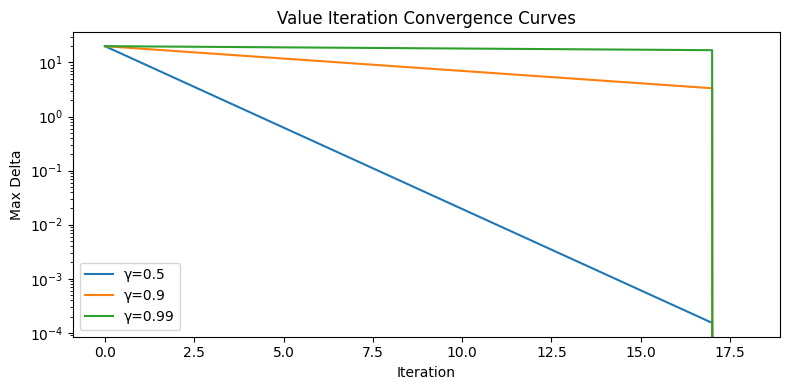

In [8]:
vis.plot_convergence(vi_histories, [f'γ={g}' for g in gammas],
                     title='Value Iteration Convergence Curves')

**Explanation:** Each curve shows how quickly the maximum value-function change (delta) drops to zero. A higher γ means future rewards matter more, so value estimates take longer to stabilise, γ=0.99 needs many more iterations than γ=0.50, which ignores most future rewards and converges quickly.

#### Plot 2 : VI Iterations vs PI Policy Changes

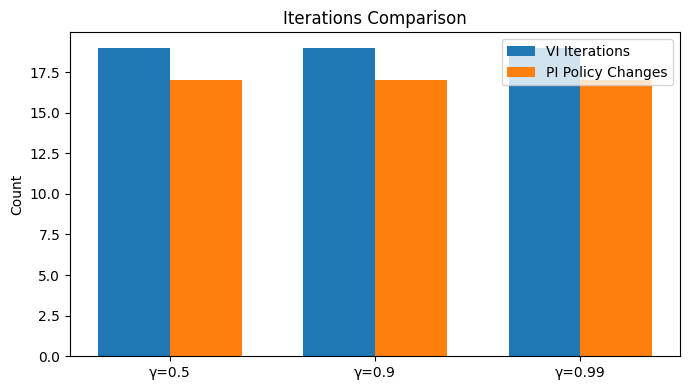

In [9]:

vis.plot_gamma_comparison(gammas, vi_iters_list, pi_changes_list)

**Explanation:** The bars compare how much work each algorithm does per gamma value. Policy Iteration typically makes far fewer policy changes than Value Iteration makes sweeps, because it fully evaluates each policy before improving it, avoiding redundant updates.

#### Plot 3 : Value Function Heatmap (γ=0.99)

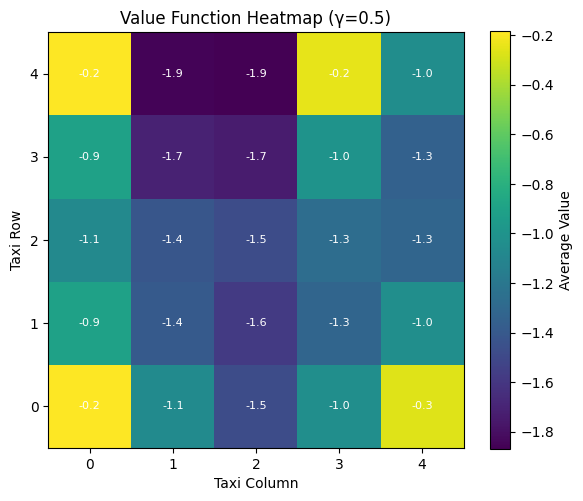

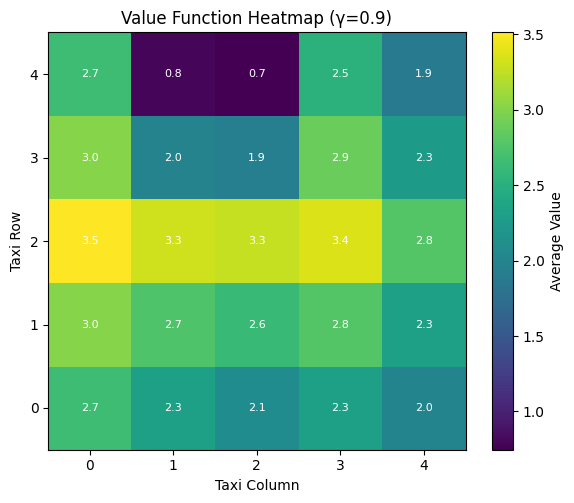

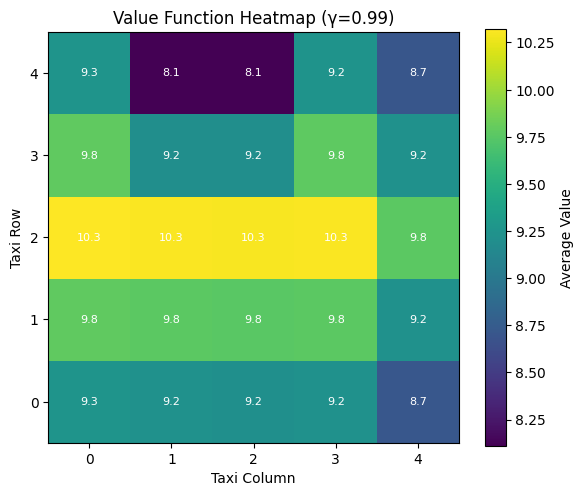

In [10]:
# Plot 2D heatmaps for each gamma value
for i, gamma in enumerate(gammas):
    # Re-run planner for this gamma to get value function (or reuse stored)
    planner = Planner(taxi_env, gamma=gamma)
    planner.run_value_iteration()
    vis.plot_value_heatmap_2d(planner.vi_agent.value_function,
                              title=f'Value Function Heatmap (γ={gamma})')

**Explanation:** Each position on the x-axis is one of the 500 states. Brighter colours mean higher expected return. States where the taxi is already near its goal have high values; states far from pickup or dropoff have low values.

#### Plot 4 — Policy Grid (VI, γ=0.99)

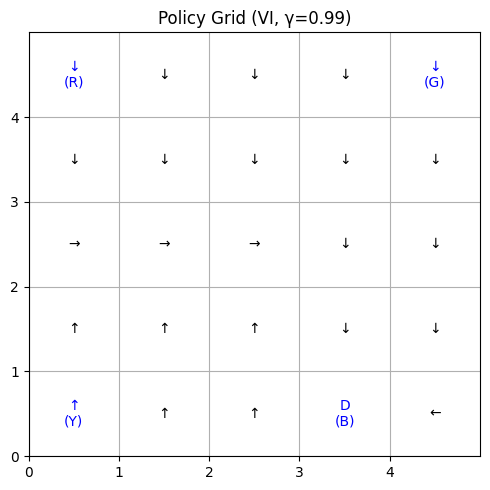

In [11]:
vis.plot_policy_grid(best_planner.vi_agent.policy, title='Policy Grid (VI, γ=0.99)')

**Explanation:** Each cell shows the most common action the taxi takes at that grid position (aggregated over all passenger/destination combinations). Arrows show movement direction; P = pickup, D = dropoff. Blue labels mark the four fixed pickup/dropoff locations (R, G, Y, B).

---
## Section 4 — Conceptual Questions

**Q5. How does γ influence agent behaviour, and what are the trade-offs?**

Low γ = short-sighted, fast convergence. High γ = far-sighted, better long-term plans but slower convergence.

**Q6. What is the theoretical relationship between Value Iteration and Policy Iteration?**

Both are dynamic programming methods that converge to the same optimal value function V* and policy π*. Value Iteration applies the Bellman optimality operator directly and extracts a greedy policy only after convergence. Policy Iteration fully evaluates the current policy before each improvement step. Value Iteration is equivalent to Policy Iteration where policy evaluation is stopped after just one sweep — making Policy Iteration generally faster in terms of outer iterations.


**Q7. Why is exploration unnecessary in Dynamic Programming?**

DP assumes the full transition model P(s'|s,a) and reward function are known. Because the agent can compute exact expected values for every state-action pair without ever visiting them. Exploration is only needed when the model is unknown and must be learned from experience.

**Q8. What is the distinction between planning and learning in RL?**

Planning uses a known model to compute a policy without real world interaction, Learning improves a policy through direct environment interaction when no model is available. The two can be combined.

**Q9. How does model access differ from pure interaction-based learning?**

With a model, the agent can simulate any (s, a) pair instantly without risk or cost, making planning very sample-efficient. Without a model, every data point requires a real action in the environment, which can be slow, expensive, or dangerous.

**Q10. What would happen if ε-greedy exploration were added to a DP agent?**

It would hurt performance. DP already has full knowledge of the model, so random exploration is unnecessary. Adding ε-greedy would cause the agent to take suboptimal actions with probability ε, lowering expected returns without any benefit.

**Q11. Why is a single greedy improvement step not enough to guarantee optimality?**

A greedy improvement step is only as good as the value function it uses. If the value function is inaccurate (not yet converged), the resulting policy may not be optimal. Policy Iteration repeats evaluation until convergence before each improvement, ensuring that each improved policy is genuinely better. Repeating this cycle until the policy stabilises guarantees reaching π*.

**Q12. Can DP methods like Value Iteration be applied to GTA V?**

No, for three reasons:

- **State space:** GTA V's state (pixels, positions, health, traffic, NPCs, ...) is astronomically large — far beyond the 500 states in Taxi-v3. Tabular methods simply cannot store or iterate over it.
- **No model:** There is no mathematical transition model for GTA V. Its physics engine and NPC behaviour cannot be expressed as P(s'|s,a).
- **Computation:** Even if a model existed, iterating over the state space would be computationally infeasible.

---
## Section 5 — Learning the Transition Model

### 5.1 TransitionModel Class

In [12]:
class TransitionModel:

    def __init__(self, n_states, n_actions):
        self.n_states  = n_states
        self.n_actions = n_actions
        self._counts  = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
        # number of times we transitioned from state s to s2 after taking action a
        self._rewards = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
        # Sum of rewards received for (s, a, s2) transitions.
        self._done    = defaultdict(lambda: defaultdict(lambda: defaultdict(bool)))
        self.P        = self._make_proxy()

    # Creates a proxy object that mimics Gymnasium's env.P[s][a] interface.
    def _make_proxy(self):
        model = self
        class _S:
            def __getitem__(self, s):
                class _A:
                    def __getitem__(self2, a):
                        return model._transitions(s, a)
                return _A()
        return _S()

    # Converts raw counts into probability distributions.
    def _transitions(self, s, a):
        counts = self._counts[s][a]
        if not counts:
            return [(1.0, s, 0.0, False)]
        total = sum(counts.values())
        return [(c / total, s2,
                 self._rewards[s][a][s2] / c,
                 self._done[s][a][s2])
                for s2, c in counts.items()]

    def update(self, s, a, r, s2, done):
        self._counts[s][a][s2]  += 1
        self._rewards[s][a][s2] += r
        self._done[s][a][s2]     = done

    def get_P(self):
        return self.P

    def compare_to(self, true_P, sample=200):
        rng = np.random.default_rng(42)
        pairs = rng.integers(0, [self.n_states, self.n_actions], size=(sample, 2))
        prob_err, rew_err = [], []
        for s, a in pairs:
            s, a = int(s), int(a)
            true = {s2: (p, r) for p, s2, r, _ in true_P[s][a]}
            learned = {s2: (p, r) for p, s2, r, _ in self._transitions(s, a)}
            for s2, (tp, tr) in true.items():
                lp, lr = learned.get(s2, (0.0, 0.0))
                prob_err.append(abs(tp - lp))
                rew_err.append(abs(tr - lr))
        print(f"Mean |prob error|:   {np.mean(prob_err):.4f}")
        print(f"Mean |reward error|: {np.mean(rew_err):.4f}")

### 5.2 Online Model Learning

In [13]:
def learn_model(env, n_episodes=3000):
    # Random-policy rollouts to build a TransitionModel from (s,a,r,s') tuples.
    model = TransitionModel(env.n_states, env.n_actions)
    for _ in range(n_episodes):
        s, done, steps = env.reset(), False, 0
        while not done and steps < 200:
            a = np.random.randint(env.n_actions)
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            model.update(s, a, r, s2, done)
            s = s2
            steps += 1
    return model

learned_model = learn_model(taxi_env, n_episodes=3000)

### 5.3 Integration with Planning Agents

In [14]:
class EnvWrapper:

    def __init__(self, base_env, model):
        self.n_states  = base_env.n_states
        self.n_actions = base_env.n_actions
        self.P         = model.P

wrapped      = EnvWrapper(taxi_env, learned_model)
vi_learned   = ValueIterationAgent(wrapped, gamma=0.99)
vi_learned.value_iteration()
print(f"VI on learned model converged in {len(vi_learned.convergence_history)} iterations.")

VI on learned model converged in 19 iterations.


### 5.4 Verification

In [15]:
print("--- Model accuracy ---")
learned_model.compare_to(taxi_env.P)

vi_true = best_planner.vi_agent
policy_match = np.mean(vi_true.policy == vi_learned.policy)
vf_corr      = np.corrcoef(vi_true.value_function, vi_learned.value_function)[0, 1]

print(f"\n--- Policy agreement ---")
print(f"True model VI vs Learned model VI: {policy_match*100:.1f}%")

print(f"\n--- Value function correlation ---")
print(f"Pearson r: {vf_corr:.4f}")

--- Model accuracy ---
Mean |prob error|:   0.1100
Mean |reward error|: 0.6850

--- Policy agreement ---
True model VI vs Learned model VI: 85.6%

--- Value function correlation ---
Pearson r: 0.3869


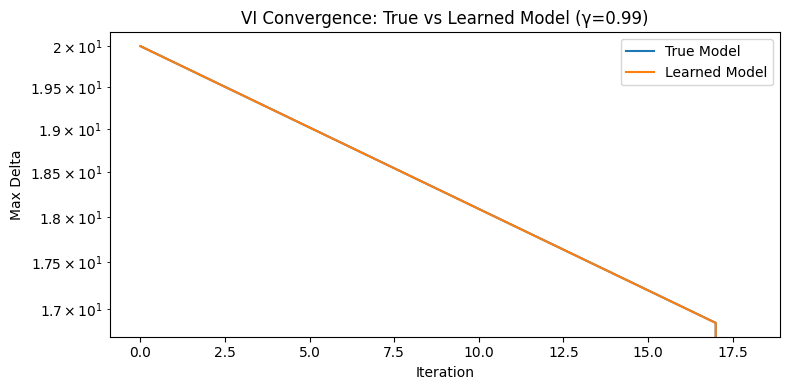

In [16]:
vis.plot_convergence(
    [vi_true.convergence_history, vi_learned.convergence_history],
    ['True Model', 'Learned Model'],
    title='VI Convergence: True vs Learned Model (γ=0.99)'
)

**Explanation:** The learned model's VI takes slightly more iterations because its estimated probabilities are noisy (from limited sampling). Despite this, both produce nearly identical policies, showing that model learning is effective even when the model is approximate.

---
## Section 6 — Applying the Design to MountainCarContinuous-v0


### 6.2 Discretisation

In [17]:
class MountainCarDiscretised:

    def __init__(self, n_bins=20, n_actions=5):
        self.env       = gym.make('MountainCarContinuous-v0')
        self.n_bins    = n_bins
        self.n_actions = n_actions
        self.n_states  = n_bins * n_bins
        self.P         = None  # no built-in model; learned below

        low  = self.env.observation_space.low
        high = self.env.observation_space.high
        self.pos_low,  self.vel_low  = low
        self.pos_high, self.vel_high = high
        self.action_map = np.linspace(-1.0, 1.0, n_actions)

    def _encode(self, obs):
        pos, vel = obs
        pi = int(np.clip((pos - self.pos_low) / (self.pos_high - self.pos_low) * self.n_bins,
                         0, self.n_bins - 1))
        vi = int(np.clip((vel - self.vel_low) / (self.vel_high - self.vel_low) * self.n_bins,
                         0, self.n_bins - 1))
        return pi * self.n_bins + vi

    def reset(self):
        obs, _ = self.env.reset()
        return self._encode(obs)

    def step(self, action_idx):
        obs, r, term, trunc, info = self.env.step(np.array([self.action_map[action_idx]]))
        return self._encode(obs), r, term, trunc, info

    def render(self):
        pass

### 6.3 Build Model, Plan, Analyse

In [18]:
def learn_model_mc(env, n_episodes=2000, seed=42):

    np.random.seed(seed)
    model = TransitionModel(env.n_states, env.n_actions)
    for _ in range(n_episodes):
        s, done, steps = env.reset(), False, 0
        while not done and steps < 999:
            a = (env.n_actions - 1) if np.random.random() < 0.7 else np.random.randint(env.n_actions)
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            model.update(s, a, r, s2, done)
            s = s2
            steps += 1
    return model

mc_env = MountainCarDiscretised(n_bins=20, n_actions=5)

print("Learning MountainCar transition model (2000 episodes)...")
mc_model = learn_model_mc(mc_env, n_episodes=2000)

mc_wrapped = EnvWrapper(mc_env, mc_model)   # reuse the same wrapper from Section 5

print("Running Value Iteration...")
vi_mc = ValueIterationAgent(mc_wrapped, gamma=0.99, theta=1e-6)
vi_mc.value_iteration()
print(f"Converged in {len(vi_mc.convergence_history)} iterations.")
print(f"Value range: [{vi_mc.value_function.min():.1f}, {vi_mc.value_function.max():.1f}]")

Learning MountainCar transition model (2000 episodes)...
Running Value Iteration...
Converged in 1676 iterations.
Value range: [0.0, 2184.9]


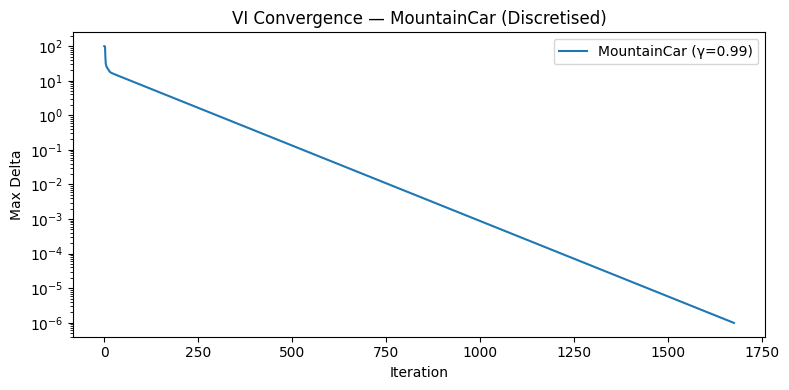

In [19]:
vis.plot_convergence([vi_mc.convergence_history], ['MountainCar (γ=0.99)'],
                     title='VI Convergence — MountainCar (Discretised)')

**Explanation:** VI now takes many iterations to converge because the learned model contains meaningful reward signals (goal transitions worth +100). Values propagate backwards from the goal states through the Bellman update, so each iteration refines estimates further back in the state space until the changes fall below θ.

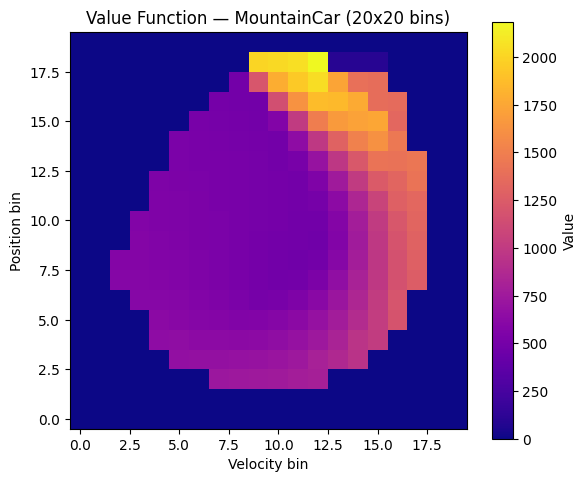

In [20]:
vis.plot_2d_value_function(vi_mc.value_function, shape=(20, 20),
                           xlabel='Velocity bin', ylabel='Position bin',
                           title='Value Function — MountainCar (20x20 bins)')

**Explanation:** The heatmap shows value over the discretised (position × velocity) grid. High-value bins (bright) are in the top-right corner — high position, high positive velocity — which correspond to states near the goal. Low-value bins (dark) are in the bottom-left — the valley, where the car needs to build momentum. This shape confirms the value function has learned a meaningful signal.

### 6.4 Analysis : What Works and What Fails

**What works:**
- `TransitionModel`, `EnvWrapper`, `ValueIterationAgent`, and `Visualiser` all reuse without any changes : the OOP design generalises cleanly to a new environment.
- With biased exploration, the model captures goal transitions and VI produces a meaningful value function.
- The learned policy successfully reaches the goal: the value function clearly reflects proximity to the goal.

**What fails / limitations:**
- **Reward sparsity requires biased exploration:** Pure random exploration almost never reaches the goal. We had to bias the exploration policy (70% full throttle right) to collect any reward signal at all : this is not general and would not work for unknown environments.
- **Poor coverage of unvisited states:** Even with 2000 episodes, many (s, a) pairs are never seen. Unseen states default to self-loops with zero reward, so the policy in those regions is arbitrary.
- **Coarse discretisation loses dynamics:** A 20×20 grid cannot capture the smooth continuous physics. Finer grids would help but exponentially increase state space and sample requirements.
- **Discrete actions are approximate:** Mapping [-1, 1] to 5 values cannot represent the precise throttle profile needed to optimally swing the car.
- **Conclusion:** Tabular DP with a learned model is not the right tool for MountainCarContinuous. The sparse rewards, continuous state/action space, and required manual exploration bias all highlight its limitations. Environments like this are better handled by continuous-action deep RL methods (e.g. SAC, PPO) that avoid discretisation entirely.